1. Set Up & Installation

In [ ]:
import os
import cv2
import numpy as np
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

2. Data Config

In [ ]:
BASE_DIR = r"D:\Skripsi_Raphaela\conv_lstm\dataset\dataset_split"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

CLASSES = ['static', 'approaching']
SEQ_LENGTH = 15
IMG_SIZE = 112
BATCH_SIZE = 8
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Read Folder

In [ ]:
def get_folders_and_labels(base_dir):
    vids = []
    labs = []
    for label_idx, label_name in enumerate(CLASSES): # 'static', 'approaching'
        class_dir = os.path.join(base_dir, label_name)

        if not os.path.exists(class_dir):
            continue

        # Look inside truck, excavator, rock, etc.
        for obj_folder in os.listdir(class_dir):
            obj_path = os.path.join(class_dir, obj_folder)

            if not os.path.isdir(obj_path):
                continue

            # Now find the actual video folders (e.g., VID_20260112...)
            vid_folders = [os.path.join(obj_path, d) for d in os.listdir(obj_path)
                           if os.path.isdir(os.path.join(obj_path, d))]

            for f in vid_folders:
                # Ensure the folder has enough frames
                if len([img for img in os.listdir(f) if img.lower().endswith('.jpg')]) >= SEQ_LENGTH:
                    vids.append(f)
                    labs.append(label_idx)

    return vids, labs

print("Reading data from nested manual split folders...")
train_vids, train_labs = get_folders_and_labels(TRAIN_DIR)
val_vids, val_labs = get_folders_and_labels(VAL_DIR)

print("-" * 30)
print(f"Total Training Folders  : {len(train_vids)}")
print(f"Total Validation Folders: {len(val_vids)}")
print("-" * 30)

Reading data from nested manual split folders...
------------------------------
Total Training Folders  : 480
Total Validation Folders: 106
------------------------------


3. Sliding Window & Augmentation

In [ ]:
class SlidingWindowVideoDataset(Dataset):
    def __init__(self, folders, labels, seq_length=15, img_size=112, augment=False):
        self.seq_length = seq_length
        self.img_size = img_size
        self.augment = augment
        self.sequences = []
        self.sequence_labels = []

        print(f"Building Sliding Window sequences (Augmentation: {self.augment})...")
        for folder, label in zip(folders, labels):
            # Sort the images to maintain chronological order
            images = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith('.jpg')])
            num_windows = len(images) - self.seq_length + 1

            # Create overlapping sequences from the folder's frames
            if num_windows > 0:
                for i in range(num_windows):
                    self.sequences.append(images[i : i + self.seq_length])
                    self.sequence_labels.append(label)

        print(f"Total sequences created: {len(self.sequences)}")

    def __len__(self):
        return len(self.sequences)

    def apply_augmentation(self, frames):
        # 1. Random Horizontal Flip
        if random.random() > 0.5:
            frames = [cv2.flip(f, 1) for f in frames]

        # 2. Random Rotation (-10 to 10 degrees)
        angle = random.uniform(-10, 10)
        M = cv2.getRotationMatrix2D((self.img_size//2, self.img_size//2), angle, 1.0)
        frames = [cv2.warpAffine(f, M, (self.img_size, self.img_size)) for f in frames]

        # 3. Random Brightness & Contrast (Crucial for generalizing to different environments)
        if random.random() > 0.5:
            alpha = random.uniform(0.8, 1.2) # Contrast control
            beta = random.uniform(-20, 20)   # Brightness control
            frames = [np.clip(alpha * f + beta, 0, 255).astype(np.uint8) for f in frames]

        return frames

    def __getitem__(self, idx):
        frames = []
        for p in self.sequences[idx]:
            img = cv2.imread(p)

            # Fallback in case an image file is corrupted
            if img is None:
                img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (self.img_size, self.img_size))

            frames.append(img)

        # Apply augmentations only for the training dataset
        if self.augment:
            frames = self.apply_augmentation(frames)

        # Convert to numpy array and normalize pixel values to [0, 1]
        frames = np.array(frames, dtype=np.float32) / 255.0

        # PyTorch expects the shape: (Time_steps, Channels, Height, Width)
        frames = np.transpose(frames, (0, 3, 1, 2))

        return torch.tensor(frames), torch.tensor(self.sequence_labels[idx], dtype=torch.long)

train_dataset = SlidingWindowVideoDataset(train_vids, train_labs, SEQ_LENGTH, IMG_SIZE, augment=True)
val_dataset = SlidingWindowVideoDataset(val_vids, val_labs, SEQ_LENGTH, IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Building Sliding Window sequences (Augmentation: True)...
Total sequences created: 16758
Building Sliding Window sequences (Augmentation: False)...
Total sequences created: 3447


4. Define Model Architecture

In [ ]:
class VideoClassifierLite(nn.Module):
    def __init__(self, num_classes=2):
        super(VideoClassifierLite, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16), # NEW: Stabilizes training and acts as slight regularization
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), # NEW: Stabilizes training
            nn.ReLU(),

            # CRITICAL CHANGE: Reduced from (5, 5) to (3, 3)
            # This throws away fine background details so the model can't memorize the room.
            nn.AdaptiveAvgPool2d((3, 3)),
            nn.Flatten()
        )

        # Input size is now drastically smaller: 32 channels * 3 * 3 = 288
        # CRITICAL CHANGE: Reduced hidden_size from 64 to 32
        self.lstm = nn.LSTM(input_size=288, hidden_size=32, num_layers=1, batch_first=True)

        self.fc = nn.Sequential(
            nn.Dropout(0.7), # Keep the high dropout
            nn.Linear(32 * 2, num_classes) # 32 * 2 because we concat first and last frame
        )

    def forward(self, x):
        b, t, c, h, w = x.size()
        x = x.view(b * t, c, h, w)
        x = self.cnn(x)
        x = x.view(b, t, -1)

        lstm_out, _ = self.lstm(x)

        # Extract only the first and last frame features
        first_feat = lstm_out[:, 0, :]
        last_feat = lstm_out[:, -1, :]
        combined = torch.cat((first_feat, last_feat), dim=1)

        return self.fc(combined)

# Initialize the Lite model instead
model = VideoClassifierLite().to(DEVICE)

5. Loop Training

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_val_acc = 0
patience = 15
counter = 0

for epoch in range(1, 101):
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct = 0, 0
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch} [TRAIN]"):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    # Calculate metrics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    t_acc = train_correct / len(train_dataset)
    v_acc = val_correct / len(val_dataset)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch} Summary (LR: {current_lr:.6f}):")
    print(f" >> Train Loss: {avg_train_loss:.4f} | Train Acc: {t_acc:.4f}")
    print(f" >> Val Loss:   {avg_val_loss:.4f} | Val Acc:   {v_acc:.4f}")

    # --- MODEL CHECKPOINTING & EARLY STOPPING ---
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), "best_model_convlstm.pth")
        print(f" [!] Validation accuracy improved. Model saved to 'best_model_convlstm.pth'")
        counter = 0 # Reset patience counter
    else:
        counter += 1
        print(f" [i] No improvement in validation accuracy. Patience: {counter}/{patience}")

        if counter >= patience:
            print("\n" + "="*50)
            print("EARLY STOPPING TRIGGERED!")
            print(f"Stopping training at Epoch {epoch}. Best Val Acc: {best_val_acc:.4f}")
            print("="*50)
            break
    print("-" * 60)

    scheduler.step(v_acc)

Epoch 1 [TRAIN]: 100%|██████████| 2095/2095 [04:19<00:00,  8.07it/s]


Epoch 1 Summary (LR: 0.000100):
 >> Train Loss: 0.6060 | Train Acc: 0.6812
 >> Val Loss:   0.7631 | Val Acc:   0.5376
 [!] Validation accuracy improved. Model saved to 'best_model_convlstm.pth'
------------------------------------------------------------


Epoch 2 [TRAIN]: 100%|██████████| 2095/2095 [02:55<00:00, 11.92it/s]


Epoch 2 Summary (LR: 0.000100):
 >> Train Loss: 0.5178 | Train Acc: 0.7797
 >> Val Loss:   0.7543 | Val Acc:   0.5704
 [!] Validation accuracy improved. Model saved to 'best_model_convlstm.pth'
------------------------------------------------------------


Epoch 3 [TRAIN]: 100%|██████████| 2095/2095 [02:55<00:00, 11.92it/s]


...

Epoch 36 Summary (LR: 0.000013):
 >> Train Loss: 0.2369 | Train Acc: 0.9913
 >> Val Loss:   0.7440 | Val Acc:   0.6693
 [i] No improvement in validation accuracy. Patience: 13/15
------------------------------------------------------------


Epoch 37 [TRAIN]: 100%|██████████| 2095/2095 [03:55<00:00,  8.88it/s]


Epoch 37 Summary (LR: 0.000013):
 >> Train Loss: 0.2356 | Train Acc: 0.9927
 >> Val Loss:   0.7620 | Val Acc:   0.6681
 [i] No improvement in validation accuracy. Patience: 14/15
------------------------------------------------------------


Epoch 38 [TRAIN]: 100%|██████████| 2095/2095 [04:26<00:00,  7.87it/s]


Epoch 38 Summary (LR: 0.000013):
 >> Train Loss: 0.2351 | Train Acc: 0.9922
 >> Val Loss:   0.7958 | Val Acc:   0.6365
 [i] No improvement in validation accuracy. Patience: 15/15

EARLY STOPPING TRIGGERED!
Stopping training at Epoch 38. Best Val Acc: 0.6945


6. Confusion + Evaluation Matrix

Evaluating the best model on the Validation Set...


C:\Users\pengguna\AppData\Local\Temp\ipykernel_26264\2643934488.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_convlstm.pth


CLASSIFICATION REPORT (Precision, Recall, F1-Score)
              precision    recall  f1-score   support

      static       0.78      0.55      0.65      1745
 approaching       0.65      0.84      0.73      1702

    accuracy                           0.69      3447
   macro avg       0.71      0.70      0.69      3447
weighted avg       0.71      0.69      0.69      3447



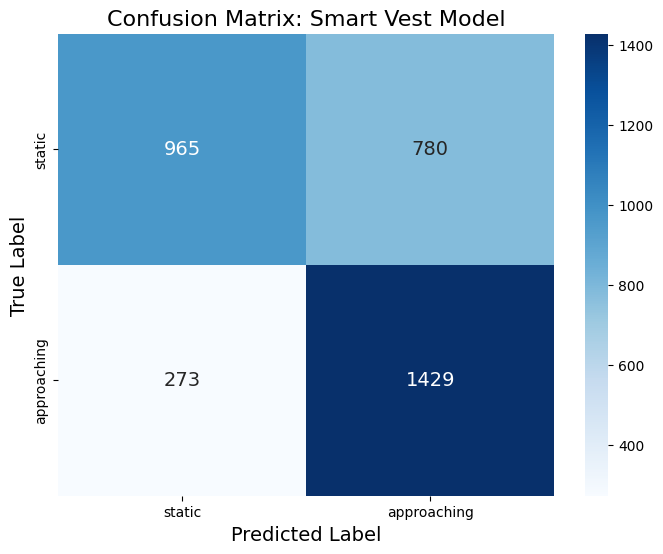

In [ ]:
def evaluate_best_model(model, val_loader, device):
    # 1. Load the best saved weights
    model.load_state_dict(torch.load("best_model_convlstm.pth"))
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    print("Evaluating the best model on the Validation Set...")
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)

            # Store predictions and true labels
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # 2. Print Evaluation Metrics
    print("\n" + "="*50)
    print("CLASSIFICATION REPORT (Precision, Recall, F1-Score)")
    print("="*50)
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                annot_kws={"size": 14}) # Make numbers larger

    plt.title('Confusion Matrix: Smart Vest Model', fontsize=16)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.show()

# Run the function
evaluate_best_model(model, val_loader, DEVICE)

7. Loss + Acc Curve

Successfully extracted data from 17 Epochs!


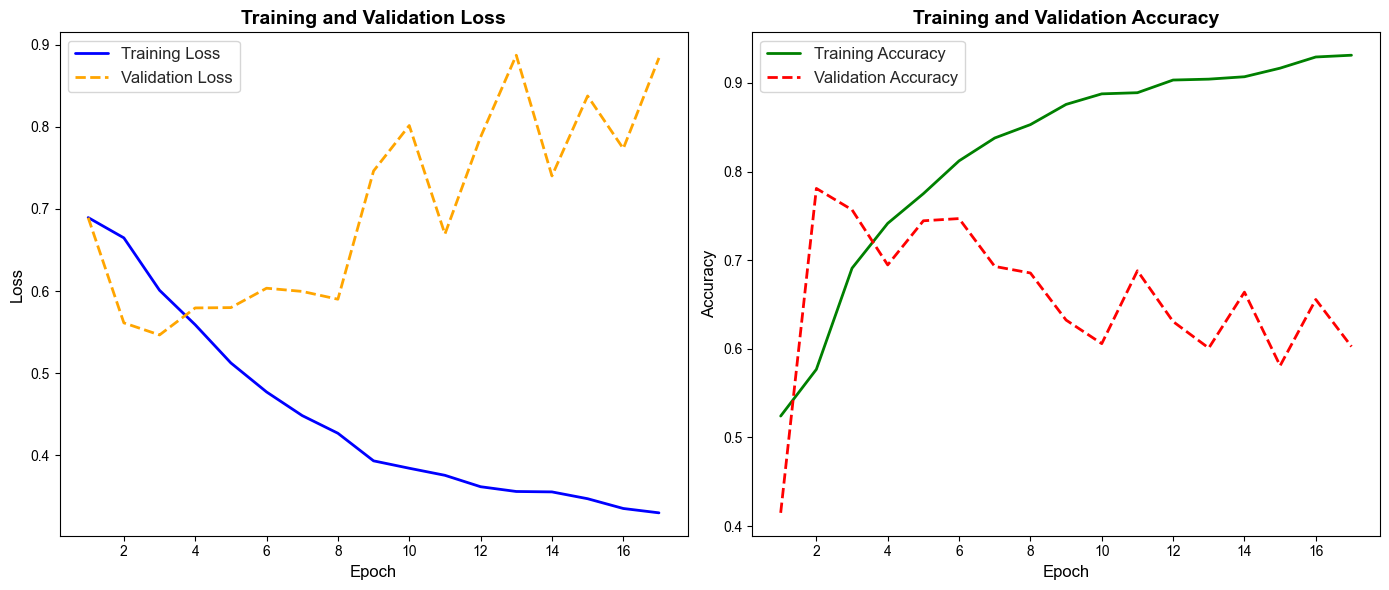

In [ ]:
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

notebook_path = r"train_convlstm.ipynb"

train_losses, val_losses = [], []
train_accs, val_accs = [], []
epochs = []

with open(notebook_path, 'r', encoding='utf-8') as f:
    nb_data = json.load(f)

# THE FIX: Use reversed() to search from the bottom cell upwards
for cell in reversed(nb_data.get('cells', [])):
    if cell.get('cell_type') == 'code':
        source = "".join(cell.get('source', []))

        if "for epoch in range" in source and "train_loader" in source:
            outputs = cell.get('outputs', [])
            extracted_text = ""
            for out in outputs:
                if 'text' in out:
                    if isinstance(out['text'], list):
                        extracted_text += "".join(out['text'])
                    else:
                        extracted_text += out['text']

            train_matches = re.findall(r'>> Train Loss:\s*([0-9.]+)\s*\|\s*Train Acc:\s*([0-9.]+)', extracted_text)
            val_matches = re.findall(r'>> Val Loss:\s*([0-9.]+)\s*\|\s*Val Acc:\s*([0-9.]+)', extracted_text)

            # If we find output metrics in this cell, grab the data and STOP
            if len(train_matches) > 0 and len(val_matches) > 0:
                num_epochs = min(len(train_matches), len(val_matches))
                for idx in range(num_epochs):
                    train_losses.append(float(train_matches[idx][0]))
                    train_accs.append(float(train_matches[idx][1]))

                    val_losses.append(float(val_matches[idx][0]))
                    val_accs.append(float(val_matches[idx][1]))

                    epochs.append(idx + 1)
                break # Stop after finding the most recent completed run

if not epochs:
    print("Error: Could not find training data.")
else:
    print(f"Successfully extracted data from {len(epochs)} Epochs!")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    sns.set_style("whitegrid")

    # Plot Loss
    ax1.plot(epochs, train_losses, label='Training Loss', color='blue', linewidth=2)
    ax1.plot(epochs, val_losses, label='Validation Loss', color='orange', linewidth=2, linestyle='--')
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=12)

    # Plot Accuracy
    ax2.plot(epochs, train_accs, label='Training Accuracy', color='green', linewidth=2)
    ax2.plot(epochs, val_accs, label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.legend(fontsize=12)

    plt.tight_layout()
    plt.savefig('learning_curves_chapter4.png', dpi=300)
    plt.show()